In [4]:
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from statsmodels.tsa.seasonal import seasonal_decompose
import statsmodels.api as sm
from sklearn.metrics import mean_squared_error

In [5]:
Bitcoin_A = pd.read_excel("bitcoin_A.xlsx")
Bitcoin_A['DIA'] = pd.to_datetime(Bitcoin_A['DIA'], format='%Y-%m-%d')
Bitcoin_A.head()

,DIA,PRECIO,N_TRANS
0,2018-09-18,6296.631667,244259
1,2018-09-19,6335.826667,251037
2,2018-09-20,6418.562667,253674
3,2018-09-21,6669.990833,273051
4,2018-09-22,6709.312500,225537


In [10]:
v_cordoba = pd.read_excel("Cordoba.xlsx")
#Se observa que la columna de las fechas no tiene nombre, por lo que:
v_cordoba.columns=['Date','V_Resident','V_Extranj']
v_cordoba['Date'] = pd.to_datetime(v_cordoba['Date'], format='%YM%m')
v_cordoba.index = v_cordoba['Date']
del v_cordoba['Date']
print(v_cordoba.head())

            V_Resident  V_Extranj
Date                             
2005-01-01       27816       9332
2005-02-01       34920      11387
2005-03-01       45221      21663
2005-04-01       41027      29094
2005-05-01       50750      32076


## Autocorrelacion simple

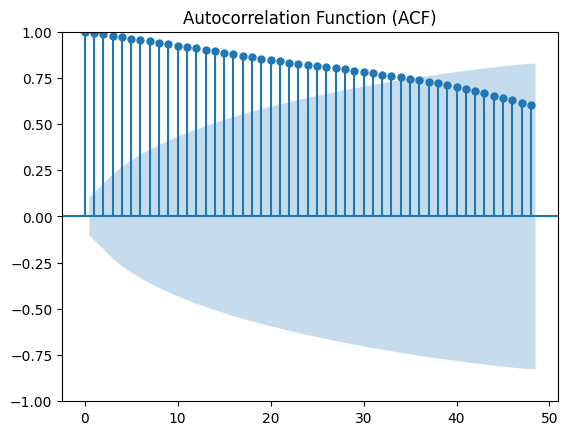

In [6]:
# Plot ACF
plot_acf(Bitcoin_A['PRECIO'], lags=48, alpha = 0.05)
plt.title('Autocorrelation Function (ACF)')
plt.show()

## Autocorrelación Parcial

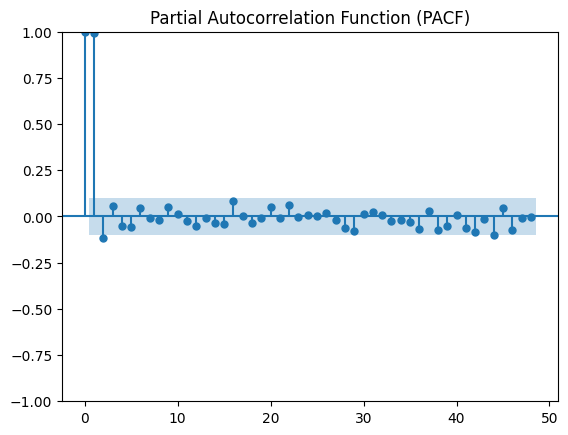

In [7]:
# Plot PACF
plot_pacf(Bitcoin_A['PRECIO'], lags=48, alpha = 0.05)
plt.title('Partial Autocorrelation Function (PACF)')
plt.show()

# Modelo Arima estacional

Text(0.5, 1.0, 'DIFF: Viajeros Residentes')

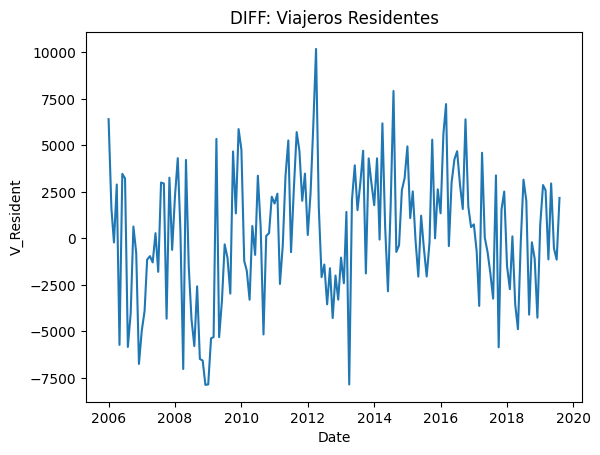

In [11]:
cordoba_diff = v_cordoba['V_Resident'].diff(12).dropna()
sns.lineplot(cordoba_diff)
plt.title('DIFF: Viajeros Residentes')

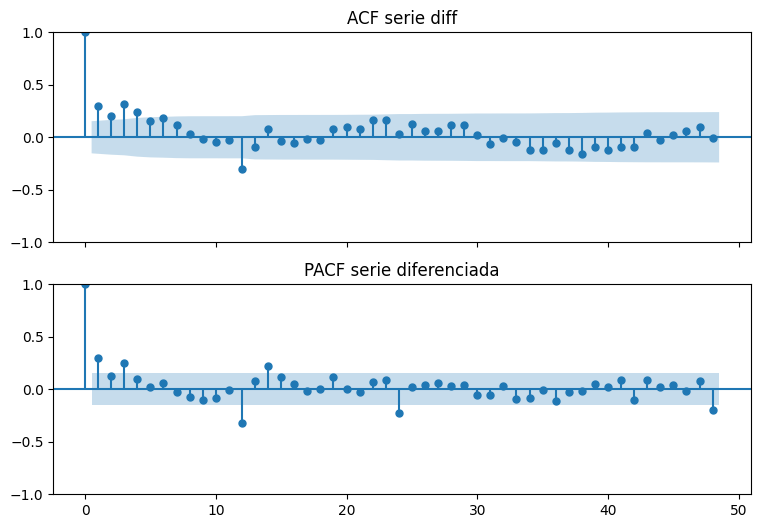

In [ ]:
fig, axs = plt.subplots(nrows=2, ncols=1,
figsize=(9, 6), sharex=True)
plot_acf(cordoba_diff, ax=axs[0],
lags=48, alpha=0.05)
axs[0].set_title('ACF serie diff')
plot_pacf(cordoba_diff, ax=axs[1],
lags=48, alpha=0.05)
axs[1].set_title('PACF serie diferenciada')